In [1]:
import pandas as pd

In [2]:
import sys
sys.path.append('/home/evlasova/mirpy')

In [3]:
from mir.common.clonotype_dataset import ClonotypeDataset
from mir.common.clonotype import ClonotypeAA

In [4]:
def get_sample_info(sample_name):
    data_path = f'/projects/immunestatus/rheum/tcrempnet'
    summary = pd.read_csv(f'{data_path}/{sample_name}_summary_tcrempnet.tsv', sep='\t')
    summary = summary[summary.cluster_size > 4]
    c0 = 829655
    c15 = len(pd.read_csv(
        f'/projects/immunestatus/rheum/airr_format/{sample_name}.tsv', sep='\t'))
    print(f'''
    sample: {sample_name}
    clusters: {len(summary)}
    overall from background: {c0}
    overall from sample: {c15}
    ''')
    return summary, c0, c15

In [5]:
as_seqs = [
    'CASSVGLFSTDTQYF',
    'CASSVGLYSTDTQYF',
    'CASSAGLFSTDTQYF',
    'CASSAGLYSTDTQYF',
    'CASSLGLFSTDTQYF',
    'CASSLGLYSTDTQYF',
    'CASSPGLFSTDTQYF',
    'CASSPGLYSTDTQYF'
]
as_clonotypes = [ClonotypeAA(cdr3aa=x) for x in as_seqs]

In [6]:
as_clonotypes = [ClonotypeAA(cdr3aa=x) for x in as_seqs]
vdjdb = ClonotypeDataset(as_clonotypes)

In [7]:
vdjdb

A dataset of 8 clonotypes and 1 clusters

In [8]:
vdjdb.get_matching_clonotypes('CASSLAPGATNEQLFF')

set()

In [9]:
def get_clonotypes(sample_name):
    data_path = f'/projects/immunestatus/rheum/tcrempnet'
    df = pd.read_csv(f'{data_path}/{sample_name}_enriched_clonotypes_tcremp.tsv', sep='\t')
    return df

In [10]:
def has_vdjdb_match(x):
    return len(vdjdb.get_matching_clonotypes(x))

def get_cluster_matches_vdjdb(df, cluster_id):
    df = df[df.cluster_id == cluster_id]
    matches = df.cdr3aa_beta.apply(has_vdjdb_match)
    return sum(matches) > 0

In [11]:
metadata = pd.read_csv("/projects/immunestatus/rheum/airr_format/metadata.tsv", sep='\t')

In [12]:
metadata

,donor_id,disease_status,b27,proj,sample_type,time_point,sample_name,fraction
0,Koc,hd,pos,GCSF,PBMC,normal blood,Koc,NaN
1,Make,hd,pos,ch45,CD45RAdepleted PBMC,after G-CSFstim,Make,NaN
2,p144852,hd,pos,ch45-2,PBMC,after G-CSFstim,p144852,NaN
3,p1004,hd,pos,child_Leu,PBMC,after G-CSFstim,p1004,NaN
4,p112635,hd,pos,ch45-2,PBMC,after G-CSFstim,p112635,NaN
...,...,...,...,...,...,...,...,...
63,Vol,as,pos,NaN,PBMC,NaN,as_Vol_PB_F,bulk
64,ZN,hd,pos,NaN,PBMC,NaN,hd_ZN_PB_F,bulk
65,Zakh,as,pos,NaN,PBMC,NaN,as_Zakh_PB_F,bulk
66,Zbot,hd,pos,NaN,PBMC,NaN,hd_Zbot_PB_F,bulk


In [13]:
metadata_h = metadata[metadata.disease_status != 'as']
metadata_h

,donor_id,disease_status,b27,proj,sample_type,time_point,sample_name,fraction
0,Koc,hd,pos,GCSF,PBMC,normal blood,Koc,NaN
1,Make,hd,pos,ch45,CD45RAdepleted PBMC,after G-CSFstim,Make,NaN
2,p144852,hd,pos,ch45-2,PBMC,after G-CSFstim,p144852,NaN
3,p1004,hd,pos,child_Leu,PBMC,after G-CSFstim,p1004,NaN
4,p112635,hd,pos,ch45-2,PBMC,after G-CSFstim,p112635,NaN
5,p434,hd,neg,child_Leu,PBMC,after G-CSFstim,p434,NaN
6,p556,hd,neg,child_Leu,PBMC,after G-CSFstim,p556,NaN
7,p744,hd,neg,child_Leu,PBMC,after G-CSFstim,p744,NaN
8,p754,hd,neg,child_Leu,PBMC,after G-CSFstim,p754,NaN
9,p1005,hd,neg,child_Leu,PBMC,after G-CSFstim,p1005,NaN


In [14]:
metadata = metadata[(metadata.disease_status == 'as') & (~metadata.sample_name.str.contains('CD8'))]

In [15]:
samples = metadata.sample_name
samples

26           as_Abd_PB_F
27           as_Abr_PB_F
28    as_Ash-110_PB_F_p0
29    as_Ash-111_PB_F_p0
30           as_Bal_PB_F
31           as_Bel_PB_F
32          as_Bost_PB_F
33         as_Chaad_PB_F
36            as_Dv_PB_F
37          as_Evst_PB_F
38            as_GE_PB_F
39           as_Gar_PB_F
40         as_Gonch_PB_F
43           as_Kal_PB_F
44           as_Kud_PB_F
47           as_Luk_PB_F
48          as_Mart_PB_F
51          as_Mikh_PB_F
56          as_Shep_PB_F
57          as_Tsib_PB_F
58         as_TwHM1_PB_F
60            as_Uv_PB_F
61           as_Vas_PB_F
62          as_Vats_PB_F
63           as_Vol_PB_F
65          as_Zakh_PB_F
67           as_i70_PB_F
Name: sample_name, dtype: object

In [16]:
sample_to_data = {}

for sample in samples:
    info = get_sample_info(sample)
    df = get_clonotypes(sample)
    info[0]['vdjdb'] = info[0].cluster_id.apply(lambda x: get_cluster_matches_vdjdb(df, x))
    sample_to_data[sample] = info


    sample: as_Abd_PB_F
    clusters: 7233
    overall from background: 829655
    overall from sample: 102283
    

    sample: as_Abr_PB_F
    clusters: 6932
    overall from background: 829655
    overall from sample: 65178
    

    sample: as_Ash-110_PB_F_p0
    clusters: 8573
    overall from background: 829655
    overall from sample: 220160
    

    sample: as_Ash-111_PB_F_p0
    clusters: 8293
    overall from background: 829655
    overall from sample: 211288
    

    sample: as_Bal_PB_F
    clusters: 8284
    overall from background: 829655
    overall from sample: 202780
    

    sample: as_Bel_PB_F
    clusters: 7065
    overall from background: 829655
    overall from sample: 75228
    

    sample: as_Bost_PB_F
    clusters: 9356
    overall from background: 829655
    overall from sample: 302672
    

    sample: as_Chaad_PB_F
    clusters: 6617
    overall from background: 829655
    overall from sample: 34613
    

    sample: as_Dv_PB_F
    clusters: 11151
    ov

In [17]:
df = sample_to_data['as_i70_PB_F'][0]

In [18]:
import seaborn as sns

In [19]:
df.cluster_size.sum()

77852

In [20]:
df.sort_values(by='cluster_size')

,cluster_id,cluster_size,sample,background,enrichment_pvalue,vdjdb
18526,18526,5,0,5,1.000000,False
18546,18546,5,0,5,1.000000,False
18562,18562,5,0,5,1.000000,False
18570,18570,5,0,5,1.000000,False
18585,18585,5,0,5,1.000000,False
...,...,...,...,...,...,...
3104,3104,250,7,243,0.945948,False
193,193,257,28,229,0.000028,False
283,283,266,17,249,0.113518,False
278,278,375,27,348,0.016636,False


<Axes: xlabel='cluster_size', ylabel='Count'>

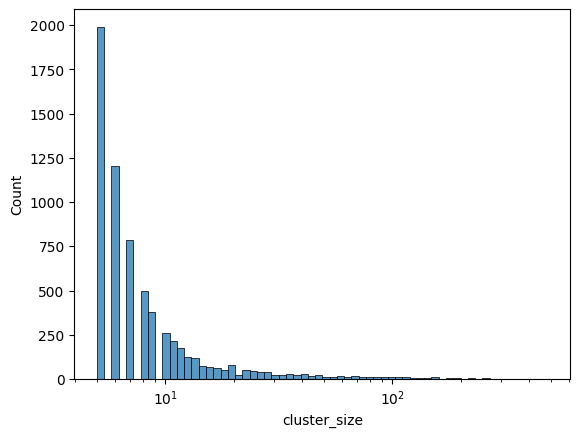

In [21]:
sns.histplot(df[['cluster_id', 'cluster_size']].drop_duplicates().cluster_size, log_scale=True)


In [22]:
import pandas as pd
import numpy as np
from scipy.stats import fisher_exact, chi2_contingency, binom
import matplotlib.pyplot as plt
import seaborn as sns

def compute_enrichment_pvalues(df, sample_overall, background_overall, method='fisher'):
    """
    df: DataFrame с колонками ['cluster_id', 'cluster_size', 'sample', 'background']
    sample_overall: общее число клонотипов в sample
    background_overall: общее число клонотипов в background
    method: 'fisher' | 'chi2' | 'binomial'
    """
    results = []

    for _, row in df.iterrows():
        cluster_id = row['cluster_id']
        a = row['sample']  # В кластере, из sample
        b = row['background']  # В кластере, из background
        c = sample_overall - a  # Вне кластера, из sample
        d = background_overall - b  # Вне кластера, из background

        if 'fisher' in method:
            _, pval = fisher_exact([[a, b], [c, d]])
        # elif method == 'chi2':
        #     _, pval, _, _ = chi2_contingency([[a, b], [c, d]])
        elif method == 'binomial':
            p = b / background_overall
            pval = min(binom.sf(k=a, n=sample_overall, p=p), binom.cdf(k=a, n=sample_overall, p=p))
        else:
            raise ValueError("method must be one of 'fisher', 'chi2', 'binomial'")

        fold_enrichment = (a / sample_overall) / ((b + 1e-9) / background_overall)
        results.append({'cluster_id': cluster_id, 'pvalue': pval, 'fold_enrichment': fold_enrichment})

    return pd.DataFrame(results)


In [23]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

def plot_volcano(df, pval_threshold=0.05, fold_threshold=2, ax=None):
    df = df.copy()

    if 'vdjdb' not in df.columns:
        raise ValueError("DataFrame должен содержать колонку 'vdjdb'")

    # Преобразования
    df['log10_pval'] = -np.log10(df['pvalue'] + 1e-10)
    df['log2_fc'] = np.log2(df['fold_enrichment'] + 1e-5)
    df['significant'] = (df['pvalue'] < pval_threshold) & (df['fold_enrichment'] > fold_threshold)
    

    # Цветовая кодировка
    def assign_color(row):
        if row['significant'] and row['vdjdb']:
            return 'sign_vdjdb' #'#084594'  # тёмно-синий
        elif row['significant']:
            return 'sign'#'#4292c6'  # голубой
        elif row['vdjdb']:
            return 'vdjdb'#'#fdbb84'  # оранжевый
        else:
            return 'no'#'#ffffb2'  # бледно-жёлтый
    
    colors = {
        'sign_vdjdb': '#084594',  # тёмно-синий
        'sign': '#4292c6',  # голубой
        'vdjdb': '#fdbb84',  # оранжевый
        'no': '#ffffb2'  # бледно-жёлтый
    }
    
    df['label'] = df.apply(assign_color, axis=1)

    # Порог Бонферрони
    bonferroni_thresh = pval_threshold / len(df)
    log10_bonferroni = -np.log10(bonferroni_thresh)
    num_significant = df['significant'].sum()
    num_significant_bonf = (df['pvalue'] < bonferroni_thresh).sum()

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))

    # Отрисовка
    sns.scatterplot(
        data=df,
        x='log2_fc',
        y='log10_pval',
        hue='label',
        style='vdjdb',
        palette=colors,
        markers={True: 's', False: '.'},
        edgecolor='black',
        linewidth=0.3,
        ax=ax,
        s=70,
        alpha=0.85,
    )

    # Линии порогов
    ax.axvline(np.log2(fold_threshold), ls='--', color='black')
    ax.axhline(-np.log10(pval_threshold), ls='--', color='black')
    ax.axhline(log10_bonferroni, ls=':', color='blue')

    ax.set_xlabel('log2(Fold Enrichment)')
    ax.set_ylabel('-log10(p-value)')
    ax.set_title(f'Significant clusters: {num_significant}, after Bonferroni: {num_significant_bonf}')
    ax.legend()

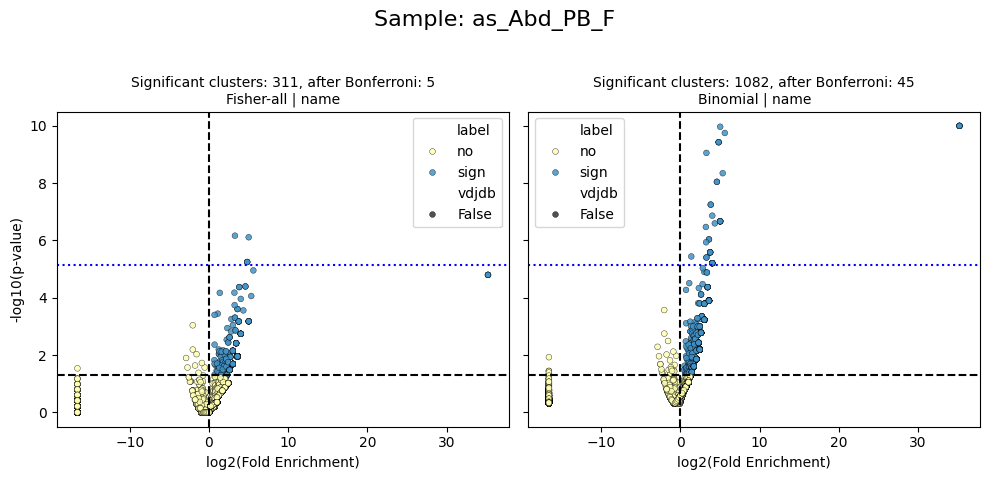

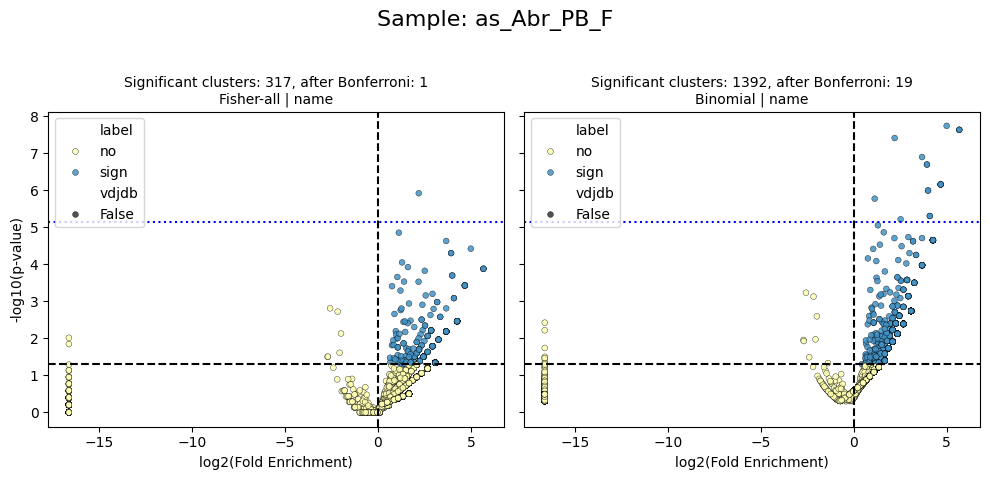

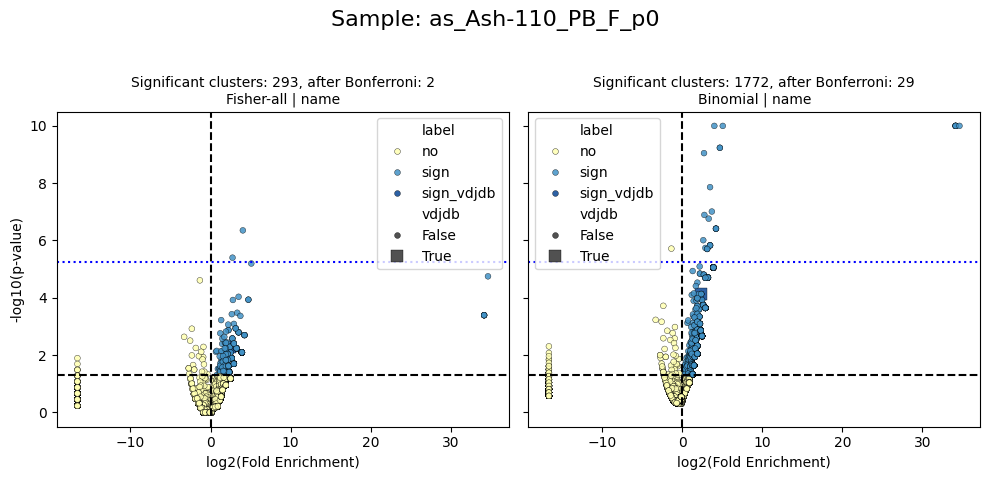

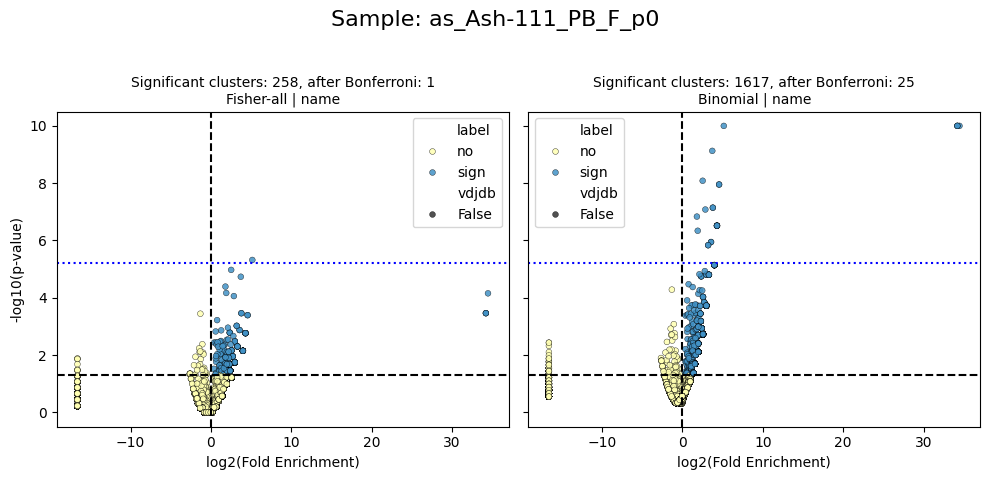

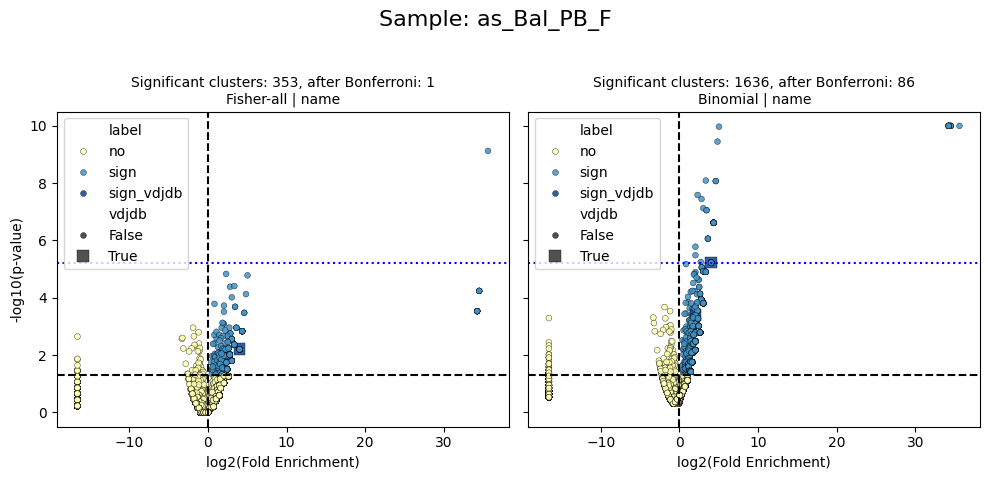

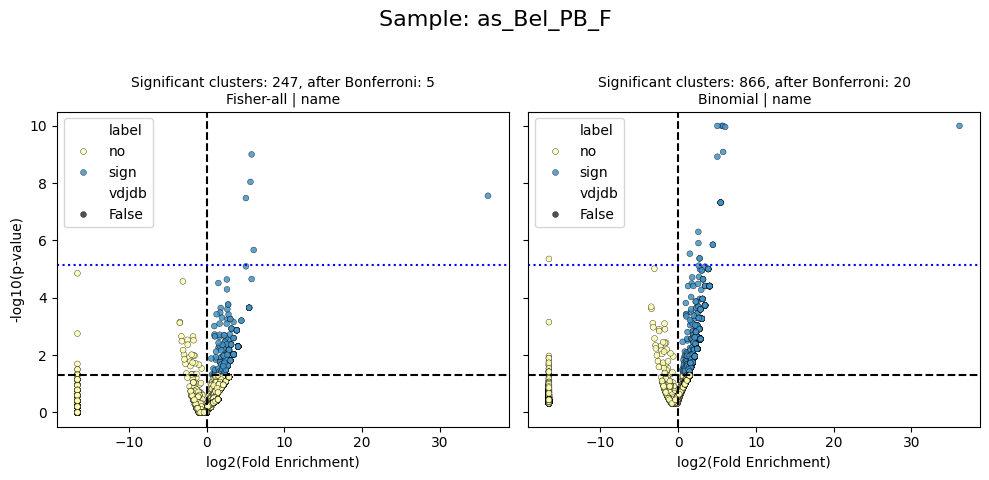

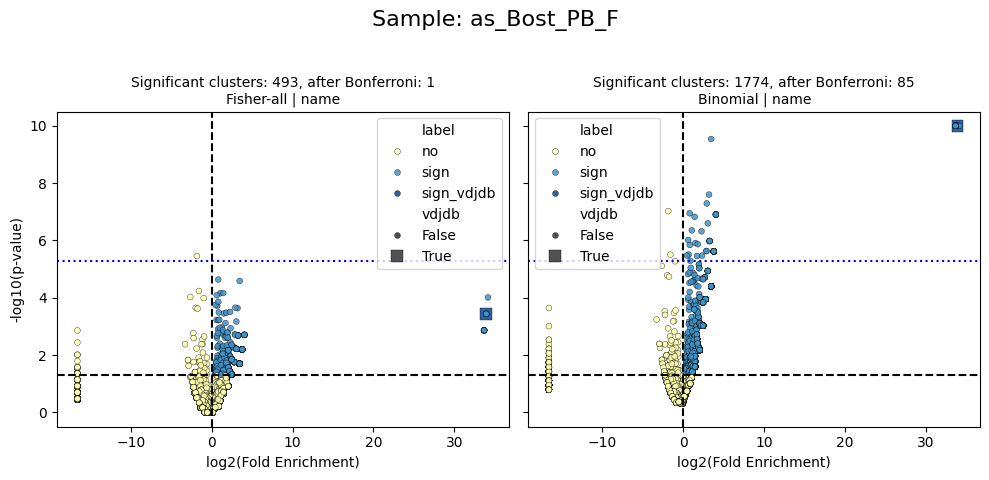

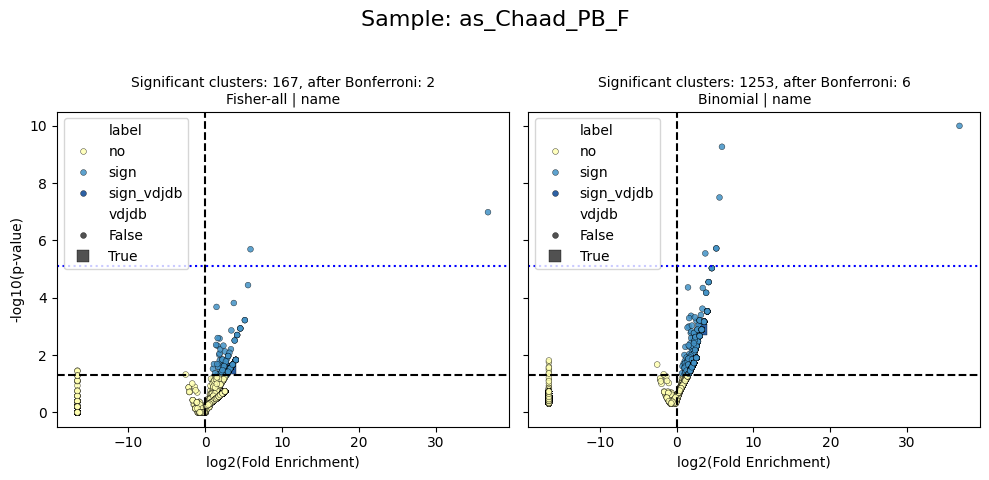

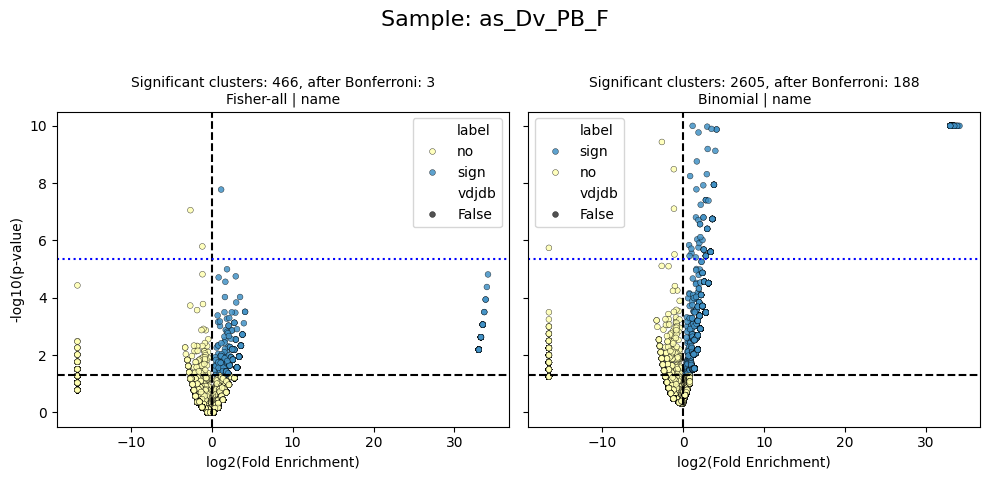

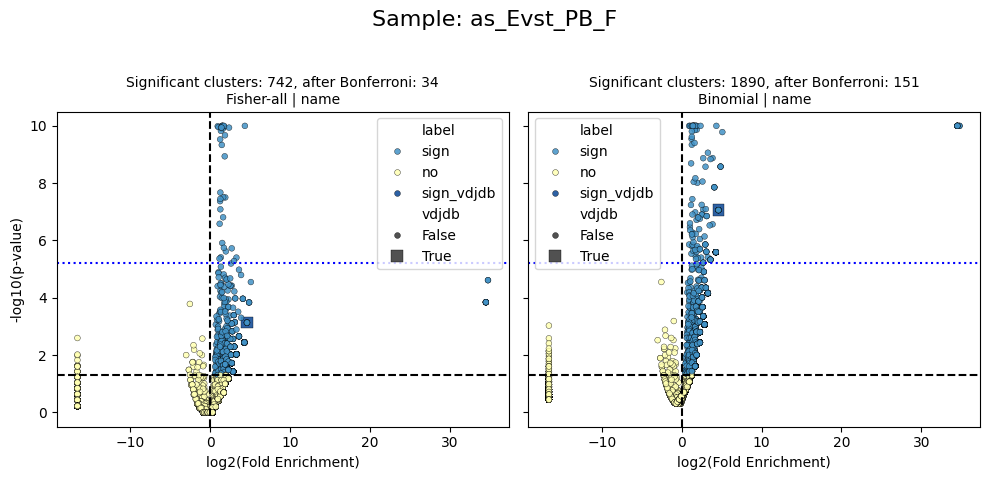

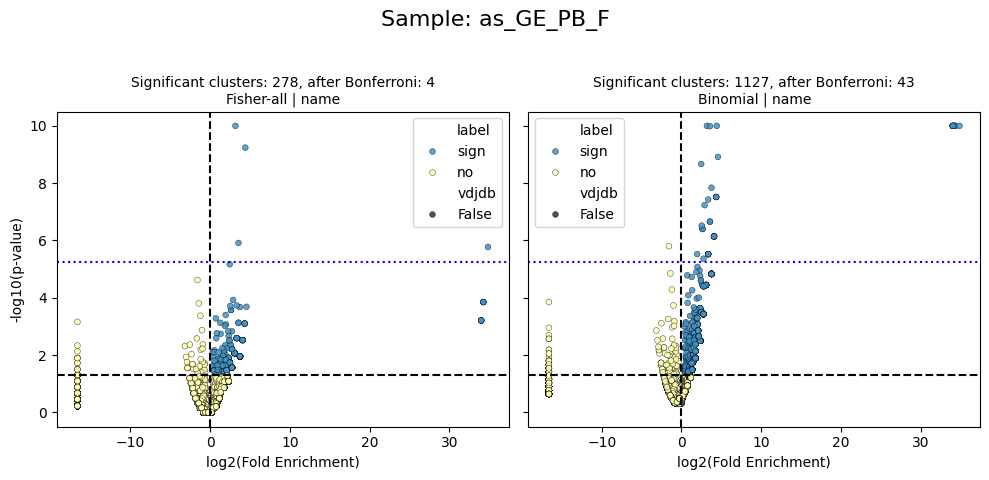

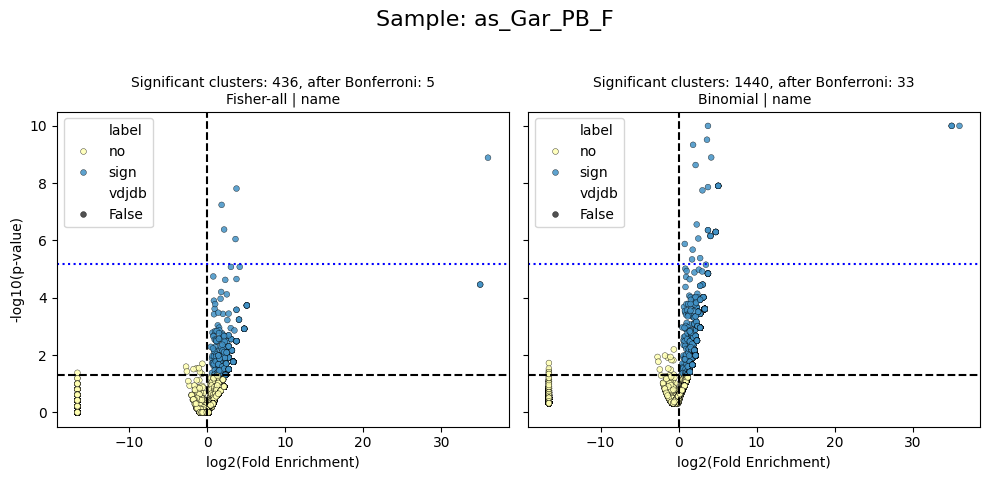

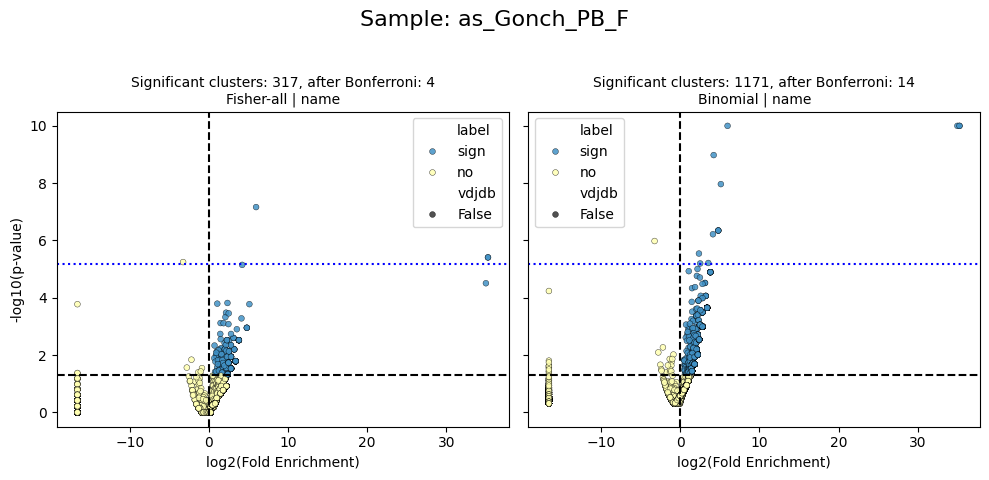

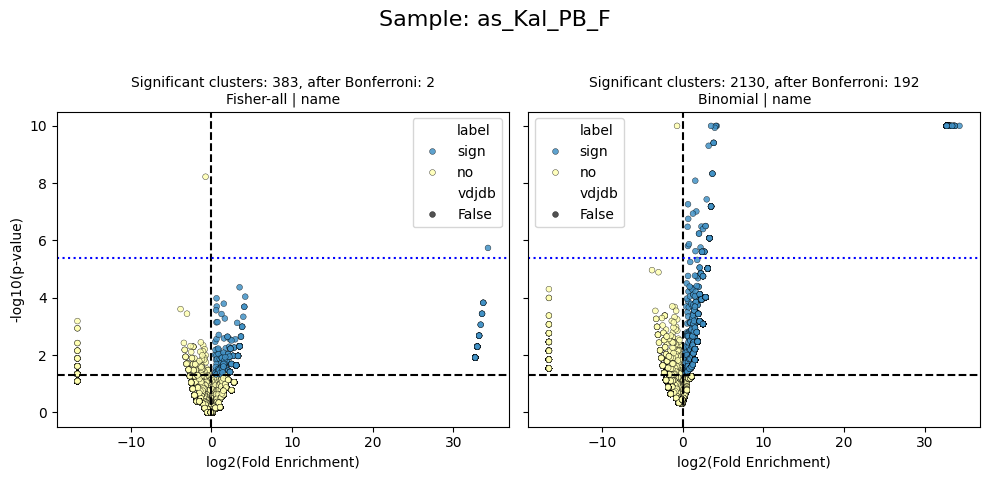

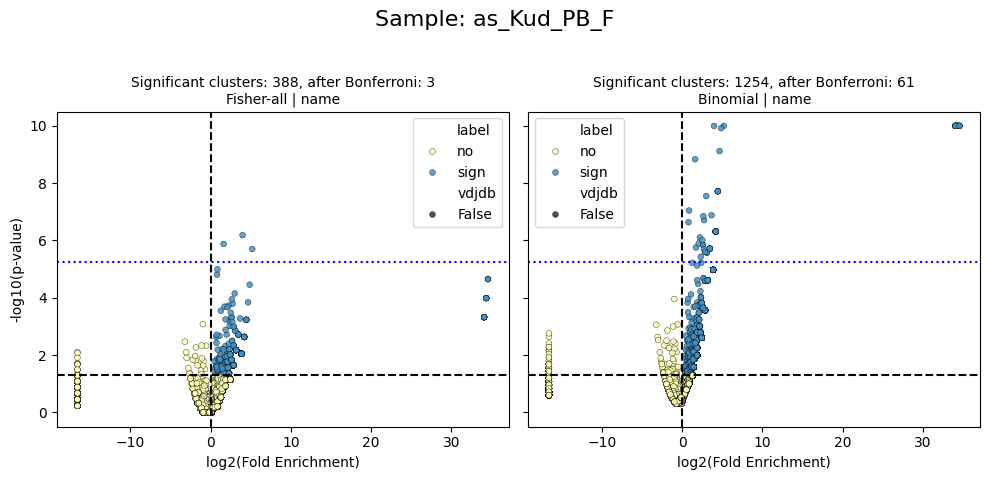

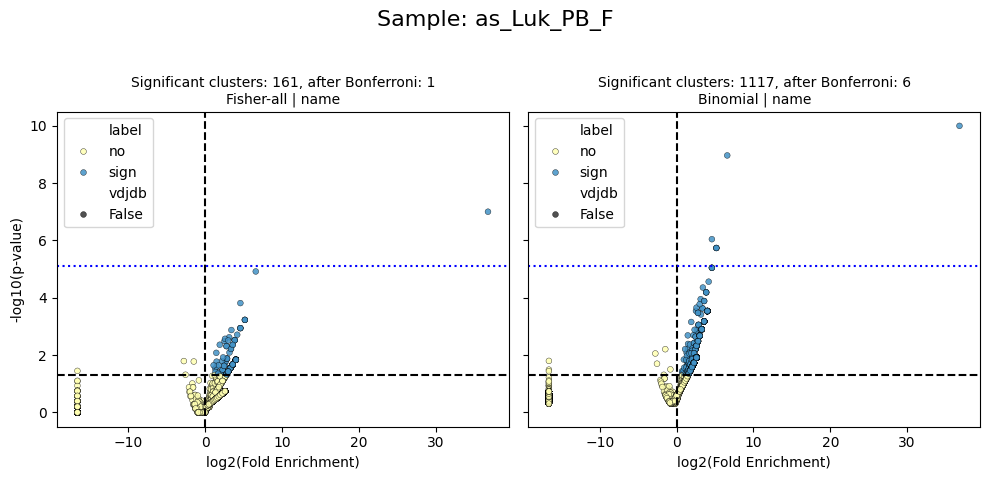

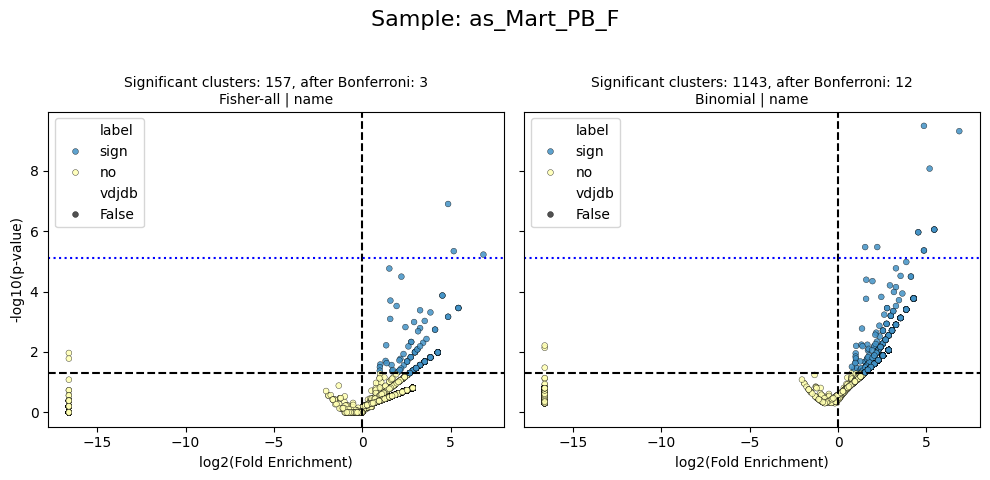

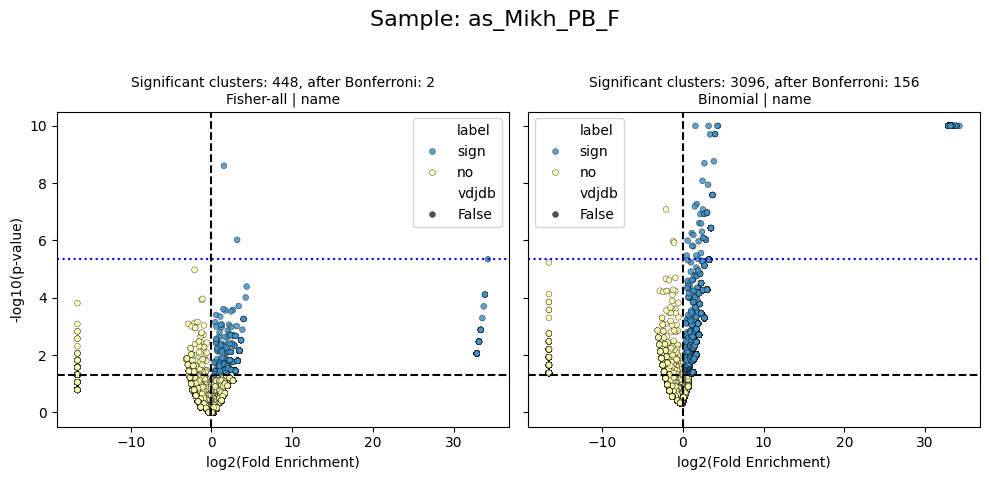

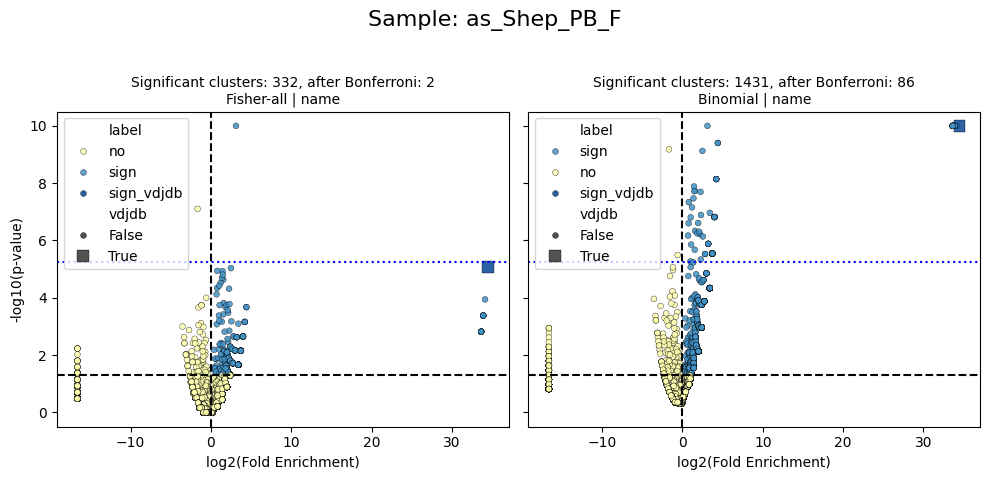

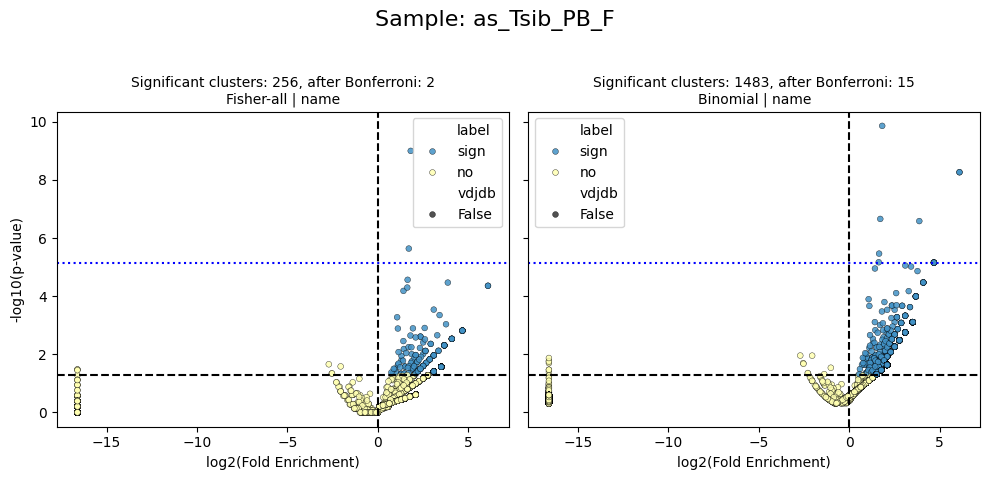

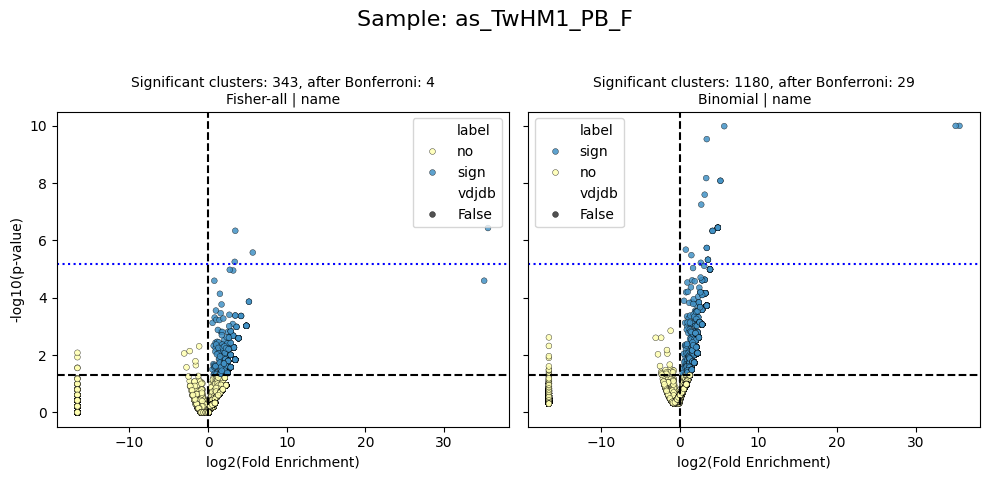

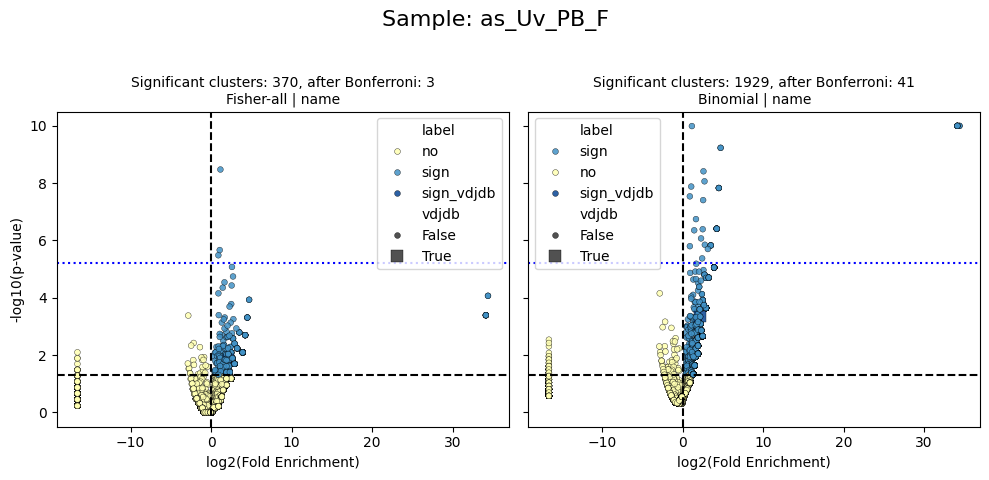

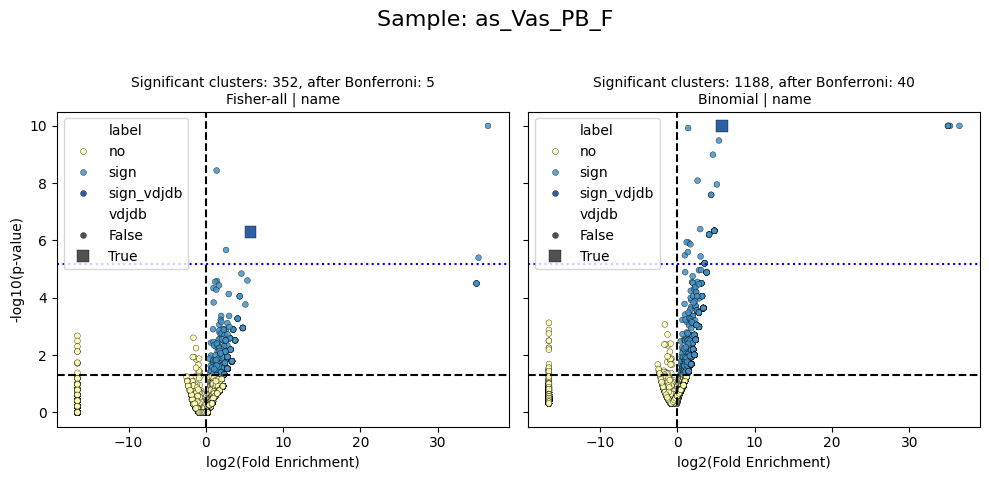

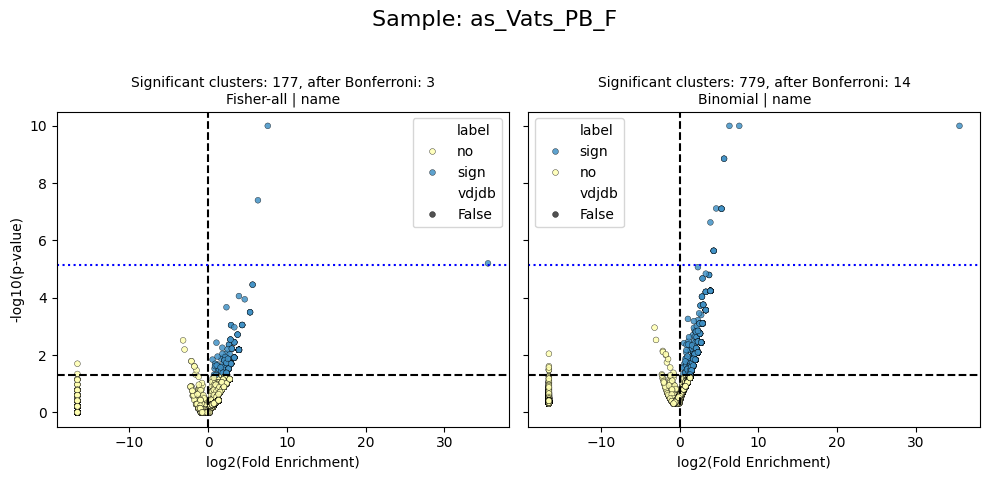

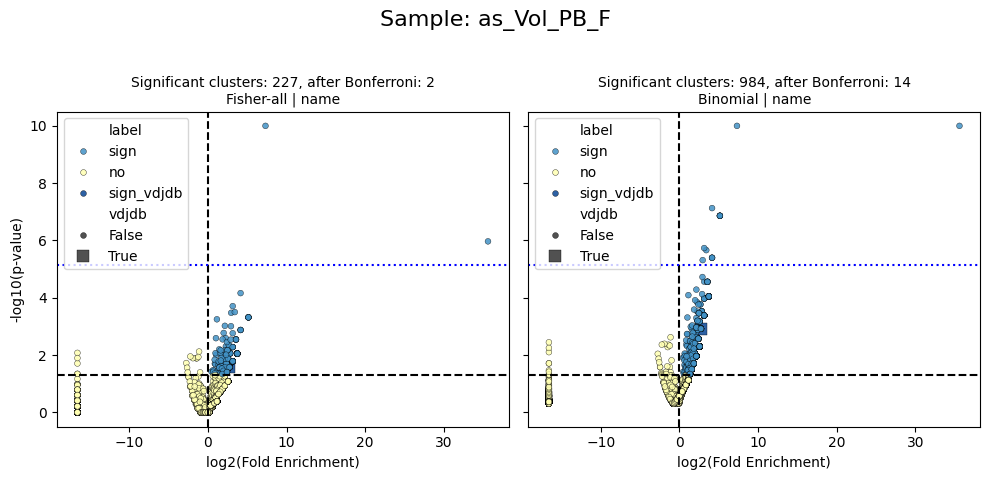

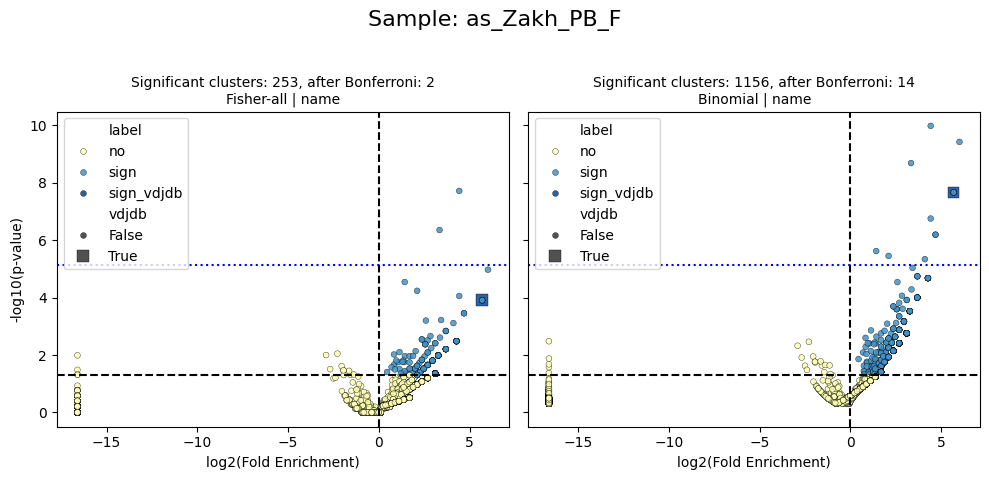

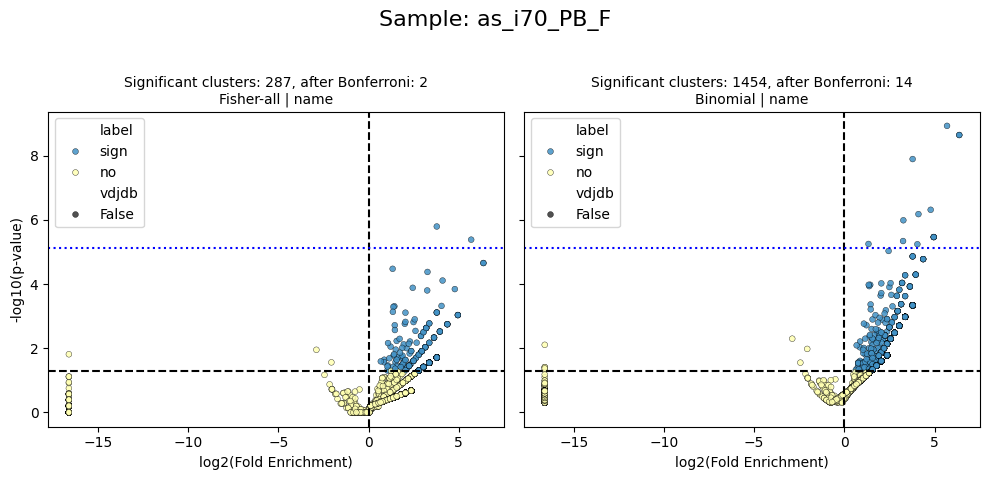

In [24]:
import matplotlib.pyplot as plt

methods = ['fisher-all', 'binomial']
sampling_sets = ['sample_to_data']
sampling_titles = ['name']
sampling_dicts = [sample_to_data]

for s in samples:
    fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)

    for i, (sampling_title, data_dict) in enumerate(zip(sampling_titles, sampling_dicts)):
        s_res = data_dict[s]
        for j, method in enumerate(methods):
            ax = axes[j]
            res_df = compute_enrichment_pvalues(
                s_res[0],
                sample_overall=s_res[2],
                background_overall=s_res[1],
                method=method.replace("-all", "")  # remove -all for compatibility
            )
            res_df = res_df.merge(s_res[0][['cluster_id', 'vdjdb']])
            plot_volcano(res_df, ax=ax, fold_threshold=1)

            # Не перезаписываем, а дописываем
            old_title = ax.get_title()
            ax.set_title(f"{old_title}\n{method.capitalize()} | {sampling_title}", fontsize=10)
            
    plt.suptitle(f'Sample: {s}', fontsize=16)
    plt.savefig(f'cluster_volcanos/{s}.png', dpi=300)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

In [25]:
from tqdm import tqdm
methods = ['binomial']
sampling_sets = ['sample_to_data']
sampling_titles = ['name']
sampling_dicts = [sample_to_data]

all_info = []
for s in tqdm(samples):
    for i, (sampling_title, data_dict) in enumerate(zip(sampling_titles, sampling_dicts)):
        s_res = data_dict[s]
        for j, method in enumerate(methods):
            res_df = compute_enrichment_pvalues(
                s_res[0],
                sample_overall=s_res[2],
                background_overall=s_res[1],
                method=method.replace("-all", "")  # remove -all for compatibility
            )
            res_df = res_df.merge(s_res[0][['cluster_id', 'vdjdb']])
            res_df = res_df[(res_df.pvalue < 0.1) & (res_df.fold_enrichment > 0)]
            res_df['sample'] = s
            all_info.append(res_df)

100%|██████████| 27/27 [00:54<00:00,  2.03s/it]


In [26]:
joint = pd.concat(all_info)

In [27]:
joint

,cluster_id,pvalue,fold_enrichment,vdjdb,sample
0,0,6.308292e-02,2.027842,False,as_Abd_PB_F
2,3,1.170812e-02,3.476300,False,as_Abd_PB_F
5,9,3.374523e-07,9.270134,False,as_Abd_PB_F
6,14,2.663717e-02,1.802526,False,as_Abd_PB_F
8,17,1.387229e-02,4.055684,False,as_Abd_PB_F
...,...,...,...,...,...
6625,18791,2.506717e-02,4.122612,False,as_i70_PB_F
6632,18929,1.656042e-02,5.153265,False,as_i70_PB_F
6641,19275,2.506717e-02,4.122612,False,as_i70_PB_F
6642,19277,1.656042e-02,5.153265,False,as_i70_PB_F


In [28]:
all_clonotypes_enriched = []
for patient in samples:
    t = get_clonotypes(patient)
    t = t[t.source == 'sample']
    t = t[t.cluster_id.isin(joint[joint['sample'] == patient].cluster_id)]
    t['cluster_id'] = patient + '_c' + t.cluster_id.astype(str)
    t['sample_name'] = patient
    all_clonotypes_enriched.append(t)

In [29]:
data = pd.concat(all_clonotypes_enriched).drop(columns=['source'])
data

,clone_id,cluster_id,cdr3aa_beta,v_beta,j_beta,enrichment_pvalue,sample_name
2,s_34,as_Abd_PB_F_c9,CASSLGSYNEQFF,TRBV7-7*01,TRBJ2-1*01,0.000066,as_Abd_PB_F
6,s_89,as_Abd_PB_F_c5842,CSASRDATYEQYF,TRBV20-1*01,TRBJ2-7*01,0.032920,as_Abd_PB_F
7,s_94,as_Abd_PB_F_c18,CASSLDRGQETQYF,TRBV7-2*01,TRBJ2-5*01,0.048443,as_Abd_PB_F
11,s_109,as_Abd_PB_F_c22,CASSPDRGRTGELFF,TRBV12-3*01,TRBJ2-2*01,0.000006,as_Abd_PB_F
13,s_119,as_Abd_PB_F_c24,CSTGVGADTQYF,TRBV29-1*01,TRBJ2-3*01,0.028424,as_Abd_PB_F
...,...,...,...,...,...,...,...
1326,s_40197,as_i70_PB_F_c282,CSTSVETQYF,TRBV29-1*01,TRBJ2-5*01,0.049759,as_i70_PB_F
1327,s_40220,as_i70_PB_F_c278,CSVGETQYF,TRBV29-1*01,TRBJ2-5*01,0.016636,as_i70_PB_F
1328,s_40237,as_i70_PB_F_c3585,CSLGEQFF,TRBV20-1*01,TRBJ2-1*01,0.012349,as_i70_PB_F
1329,s_40238,as_i70_PB_F_c3585,CSRDEQFF,TRBV20-1*01,TRBJ2-1*01,0.012349,as_i70_PB_F


In [30]:
data.to_csv('as_found_clonotypes.csv', index=False)

In [31]:
found_clonotypes = [ClonotypeAA(cdr3aa=x) for x in data.cdr3aa_beta]
dataset = ClonotypeDataset(found_clonotypes)

In [32]:
import networkx as nx
from collections import defaultdict

In [33]:
df = data

In [34]:
# 1. Построить отображение: cdr3aa → множество cluster_id
cdr3_to_clusters = defaultdict(set)
for _, row in df.iterrows():
    cdr3_to_clusters[row['cdr3aa_beta']].add(row['cluster_id'])

# 2. Построить граф кластеров, связанных общими сиквенсами
G = nx.Graph()
G.add_nodes_from(df['cluster_id'].unique())

for clusters in cdr3_to_clusters.values():
    clusters = list(clusters)
    for i in range(len(clusters)):
        for j in range(i + 1, len(clusters)):
            G.add_edge(clusters[i], clusters[j])

# 3. Компоненты связности → объединённые кластеры
cluster_mapping = {}
for new_id, component in enumerate(nx.connected_components(G)):
    for cluster_id in component:
        cluster_mapping[cluster_id] = new_id

# 4. Применить маппинг
df['merged_cluster_id'] = df['cluster_id'].map(cluster_mapping)

In [35]:
df

,clone_id,cluster_id,cdr3aa_beta,v_beta,j_beta,enrichment_pvalue,sample_name,merged_cluster_id
2,s_34,as_Abd_PB_F_c9,CASSLGSYNEQFF,TRBV7-7*01,TRBJ2-1*01,0.000066,as_Abd_PB_F,0
6,s_89,as_Abd_PB_F_c5842,CSASRDATYEQYF,TRBV20-1*01,TRBJ2-7*01,0.032920,as_Abd_PB_F,1
7,s_94,as_Abd_PB_F_c18,CASSLDRGQETQYF,TRBV7-2*01,TRBJ2-5*01,0.048443,as_Abd_PB_F,2
11,s_109,as_Abd_PB_F_c22,CASSPDRGRTGELFF,TRBV12-3*01,TRBJ2-2*01,0.000006,as_Abd_PB_F,3
13,s_119,as_Abd_PB_F_c24,CSTGVGADTQYF,TRBV29-1*01,TRBJ2-3*01,0.028424,as_Abd_PB_F,4
...,...,...,...,...,...,...,...,...
1326,s_40197,as_i70_PB_F_c282,CSTSVETQYF,TRBV29-1*01,TRBJ2-5*01,0.049759,as_i70_PB_F,4853
1327,s_40220,as_i70_PB_F_c278,CSVGETQYF,TRBV29-1*01,TRBJ2-5*01,0.016636,as_i70_PB_F,67
1328,s_40237,as_i70_PB_F_c3585,CSLGEQFF,TRBV20-1*01,TRBJ2-1*01,0.012349,as_i70_PB_F,743
1329,s_40238,as_i70_PB_F_c3585,CSRDEQFF,TRBV20-1*01,TRBJ2-1*01,0.012349,as_i70_PB_F,743


In [36]:
df['as_pattern'] = df.cdr3aa_beta.apply(lambda x: has_vdjdb_match(x) > 0)

In [37]:
df

,clone_id,cluster_id,cdr3aa_beta,v_beta,j_beta,enrichment_pvalue,sample_name,merged_cluster_id,as_pattern
2,s_34,as_Abd_PB_F_c9,CASSLGSYNEQFF,TRBV7-7*01,TRBJ2-1*01,0.000066,as_Abd_PB_F,0,False
6,s_89,as_Abd_PB_F_c5842,CSASRDATYEQYF,TRBV20-1*01,TRBJ2-7*01,0.032920,as_Abd_PB_F,1,False
7,s_94,as_Abd_PB_F_c18,CASSLDRGQETQYF,TRBV7-2*01,TRBJ2-5*01,0.048443,as_Abd_PB_F,2,False
11,s_109,as_Abd_PB_F_c22,CASSPDRGRTGELFF,TRBV12-3*01,TRBJ2-2*01,0.000006,as_Abd_PB_F,3,False
13,s_119,as_Abd_PB_F_c24,CSTGVGADTQYF,TRBV29-1*01,TRBJ2-3*01,0.028424,as_Abd_PB_F,4,False
...,...,...,...,...,...,...,...,...,...
1326,s_40197,as_i70_PB_F_c282,CSTSVETQYF,TRBV29-1*01,TRBJ2-5*01,0.049759,as_i70_PB_F,4853,False
1327,s_40220,as_i70_PB_F_c278,CSVGETQYF,TRBV29-1*01,TRBJ2-5*01,0.016636,as_i70_PB_F,67,False
1328,s_40237,as_i70_PB_F_c3585,CSLGEQFF,TRBV20-1*01,TRBJ2-1*01,0.012349,as_i70_PB_F,743,False
1329,s_40238,as_i70_PB_F_c3585,CSRDEQFF,TRBV20-1*01,TRBJ2-1*01,0.012349,as_i70_PB_F,743,False


In [38]:
df.cluster_id.value_counts()

cluster_id
as_Bost_PB_F_c123    215
as_Mikh_PB_F_c509    211
as_Evst_PB_F_c14     175
as_GE_PB_F_c135      173
as_Shep_PB_F_c76     169
                    ... 
as_i70_PB_F_c2447      2
as_i70_PB_F_c2452      2
as_i70_PB_F_c2473      2
as_i70_PB_F_c2479      2
as_i70_PB_F_c2561      2
Name: count, Length: 9505, dtype: int64

In [39]:
df.merged_cluster_id.value_counts()

merged_cluster_id
67      2530
18      2148
161     1582
26      1478
222     1419
        ... 
4887       2
4888       2
4890       2
4891       2
4892       2
Name: count, Length: 4961, dtype: int64

In [40]:
df.groupby("merged_cluster_id").nunique()[["sample_name", 'as_pattern']]
# test['as_pattern'].value_counts()

,sample_name,as_pattern
merged_cluster_id,,
0,19,1
1,1,1
2,1,1
3,1,1
4,2,1
...,...,...
4956,1,1
4957,1,1
4958,1,1


In [63]:
cluster_sizes = df.groupby("merged_cluster_id").size().reset_index(name="cluster_size")
n_patients = df.groupby('merged_cluster_id').agg({
                    'sample_name': 'nunique',     
                    'as_pattern': 'any'          
                }).reset_index().rename(columns={'sample_name': "n_patients"})
summary = pd.merge(cluster_sizes, n_patients, on="merged_cluster_id")
summary = summary.sort_values(by=["n_patients", "cluster_size"], ascending=False)


In [64]:
summary.head(10)

,merged_cluster_id,cluster_size,n_patients,as_pattern
18,18,2148,27,False
161,161,1582,24,False
35,35,1129,24,False
22,22,730,23,False
165,165,544,23,False
173,173,210,23,False
222,222,1419,22,False
105,105,1323,22,False
199,199,312,22,False
148,148,322,20,False


In [65]:
df[df.merged_cluster_id == 35]

,clone_id,cluster_id,cdr3aa_beta,v_beta,j_beta,enrichment_pvalue,sample_name,merged_cluster_id,as_pattern
88,s_1191,as_Abd_PB_F_c211,CASSTAYEQYF,TRBV7-8*01,TRBJ2-7*01,0.032920,as_Abd_PB_F,35,False
148,s_2080,as_Abd_PB_F_c328,CASSLAYEQYF,TRBV12-3*01,TRBJ2-7*01,0.000046,as_Abd_PB_F,35,False
325,s_6159,as_Abd_PB_F_c328,CASSLAYEQYF,TRBV12-3*01,TRBJ2-7*01,0.000046,as_Abd_PB_F,35,False
327,s_6165,as_Abd_PB_F_c328,CASSLSYEQYF,TRBV12-3*01,TRBJ2-7*01,0.000046,as_Abd_PB_F,35,False
698,s_16047,as_Abd_PB_F_c328,CASSLSYEQYF,TRBV12-3*01,TRBJ2-7*01,0.000046,as_Abd_PB_F,35,False
...,...,...,...,...,...,...,...,...,...
1248,s_39420,as_i70_PB_F_c3402,CASSASYEQYF,TRBV11-2*01,TRBJ2-7*01,0.038482,as_i70_PB_F,35,False
1256,s_39546,as_i70_PB_F_c3449,CASSFSYEQYF,TRBV5-1*01,TRBJ2-7*01,0.014568,as_i70_PB_F,35,False
1263,s_39575,as_i70_PB_F_c3449,CASSLDYEQYF,TRBV5-1*01,TRBJ2-7*01,0.014568,as_i70_PB_F,35,False
1264,s_39577,as_i70_PB_F_c3449,CASSLEYEQYF,TRBV5-1*01,TRBJ2-7*01,0.014568,as_i70_PB_F,35,False


In [66]:
summary[summary.as_pattern]

,merged_cluster_id,cluster_size,n_patients,as_pattern
573,573,60,9,True
4632,4632,3,1,True


In [67]:
df[df.merged_cluster_id == 165]

,clone_id,cluster_id,cdr3aa_beta,v_beta,j_beta,enrichment_pvalue,sample_name,merged_cluster_id,as_pattern
645,s_15419,as_Abd_PB_F_c1679,CASSLAGYEQYF,TRBV7-6*01,TRBJ2-7*01,0.001811,as_Abd_PB_F,165,False
646,s_15420,as_Abd_PB_F_c1679,CASSLAGFEQYF,TRBV7-6*01,TRBJ2-7*01,0.001811,as_Abd_PB_F,165,False
2488,s_95049,as_Abd_PB_F_c1679,CASSLAGYEQYF,TRBV7-6*01,TRBJ2-7*01,0.001811,as_Abd_PB_F,165,False
2490,s_95058,as_Abd_PB_F_c1679,CASSLAGYEQYF,TRBV7-6*01,TRBJ2-7*01,0.001811,as_Abd_PB_F,165,False
96,s_3539,as_Ash-110_PB_F_p0_c497,CASSASGYEQYF,TRBV5-1*01,TRBJ2-7*01,0.003703,as_Ash-110_PB_F_p0,165,False
...,...,...,...,...,...,...,...,...,...
1114,s_37350,as_i70_PB_F_c2975,CASSQQGYEQYF,TRBV3-1*01,TRBJ2-7*01,0.002338,as_i70_PB_F,165,False
1115,s_37363,as_i70_PB_F_c2975,CASSQVGYEQYF,TRBV3-1*01,TRBJ2-7*01,0.002338,as_i70_PB_F,165,False
1132,s_37850,as_i70_PB_F_c3077,CASSSQGYEQYF,TRBV5-1*01,TRBJ2-7*01,0.000923,as_i70_PB_F,165,False
1133,s_37852,as_i70_PB_F_c3077,CASSSQGYEQYF,TRBV5-1*01,TRBJ2-7*01,0.000923,as_i70_PB_F,165,False


In [47]:
as_found_seqs = df[df.merged_cluster_id == 573].cdr3aa_beta

In [48]:
found_clonotypes = [ClonotypeAA(cdr3aa=x) for x in as_found_seqs]
dataset = ClonotypeDataset(found_clonotypes)

In [49]:
dataset.clonotype_clustering

,cdr3aa,cluster
vertex ID,,
0,CASSLGLLSTDTQYF,0
1,CASSLGLPSTDTQYF,0
2,CASSLGLVSTDTQYF,0
3,CASSLGLFSTDTQYF,0
4,CASSLGLYSTDTQYF,0
5,CASSLGVPSTDTQYF,0
6,CASSLGTPSTDTQYF,0
7,CASSLGAPSTDTQYF,0
8,CASSLGYVSTDTQYF,0


In [50]:
df[df.merged_cluster_id == 4632]

,clone_id,cluster_id,cdr3aa_beta,v_beta,j_beta,enrichment_pvalue,sample_name,merged_cluster_id,as_pattern
54,s_1723,as_Vol_PB_F_c146,CASSLGLASTDTQYF,TRBV7-2*01,TRBJ2-3*01,0.02652,as_Vol_PB_F,4632,True
235,s_32441,as_Vol_PB_F_c146,CASSLGLATTDTQYF,TRBV7-2*01,TRBJ2-3*01,0.02652,as_Vol_PB_F,4632,False
261,s_33710,as_Vol_PB_F_c146,CASSLGTASTDTQYF,TRBV7-2*01,TRBJ2-3*01,0.02652,as_Vol_PB_F,4632,False


In [51]:
df[df.merged_cluster_id == 573]

,clone_id,cluster_id,cdr3aa_beta,v_beta,j_beta,enrichment_pvalue,sample_name,merged_cluster_id,as_pattern
244,s_18675,as_Ash-110_PB_F_p0_c1464,CASSLGLLSTDTQYF,TRBV5-1*01,TRBJ2-3*01,5.168061e-03,as_Ash-110_PB_F_p0,573,True
245,s_18676,as_Ash-110_PB_F_p0_c1464,CASSLGLPSTDTQYF,TRBV5-1*01,TRBJ2-3*01,5.168061e-03,as_Ash-110_PB_F_p0,573,True
246,s_18677,as_Ash-110_PB_F_p0_c1464,CASSLGLVSTDTQYF,TRBV5-1*01,TRBJ2-3*01,5.168061e-03,as_Ash-110_PB_F_p0,573,True
249,s_18696,as_Ash-110_PB_F_p0_c1464,CASSLGAVETDTQYF,TRBV5-1*01,TRBJ2-3*01,5.168061e-03,as_Ash-110_PB_F_p0,573,False
939,s_111975,as_Ash-110_PB_F_p0_c1464,CASSLGSIRTDTQYF,TRBV5-1*01,TRBJ2-3*01,5.168061e-03,as_Ash-110_PB_F_p0,573,False
963,s_112425,as_Ash-110_PB_F_p0_c1464,CASSLGAYSTDTQYF,TRBV5-1*01,TRBJ2-3*01,5.168061e-03,as_Ash-110_PB_F_p0,573,True
967,s_112466,as_Ash-110_PB_F_p0_c1464,CASSLGTVDTDTQYF,TRBV5-1*01,TRBJ2-3*01,5.168061e-03,as_Ash-110_PB_F_p0,573,False
133,s_3471,as_Bal_PB_F_c466,CASSVGLYSTDTQYF,TRBV9*01,TRBJ2-3*01,6.271419e-03,as_Bal_PB_F,573,True
200,s_5030,as_Bal_PB_F_c636,CASSLGPTSTDTQYF,TRBV5-1*01,TRBJ2-3*01,1.049488e-02,as_Bal_PB_F,573,False
227,s_6292,as_Bal_PB_F_c466,CASSVGVFSTDTQYF,TRBV9*01,TRBJ2-3*01,6.271419e-03,as_Bal_PB_F,573,True


In [52]:
import logomaker

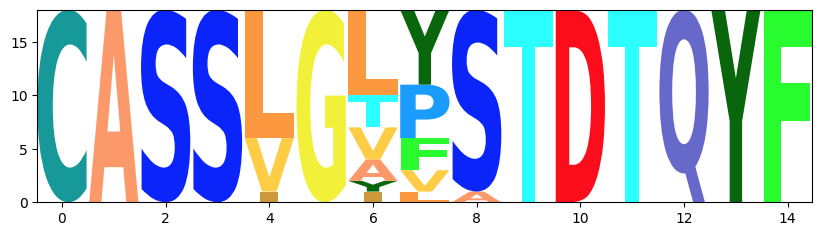

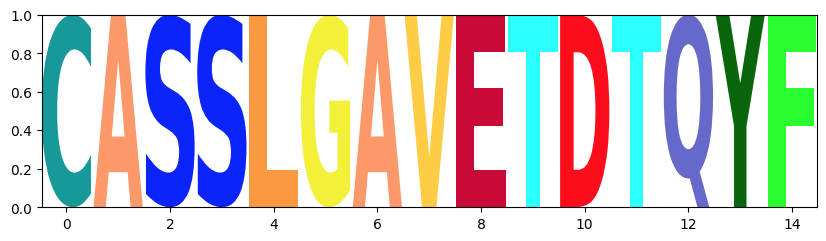

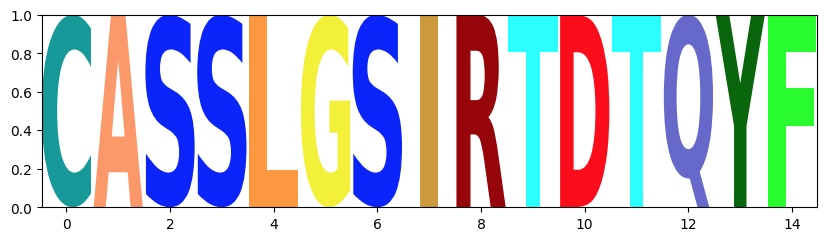

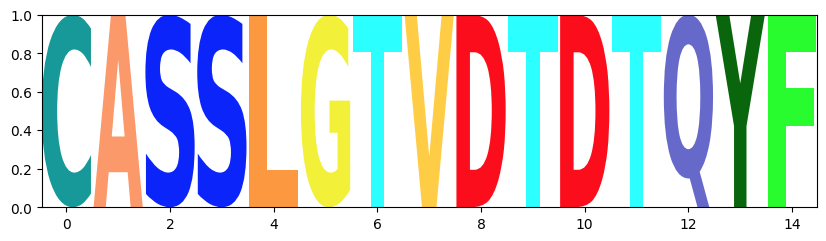

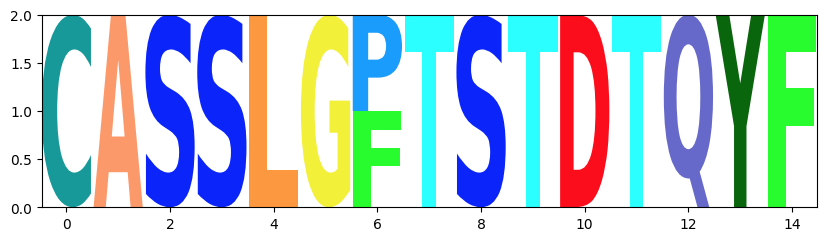

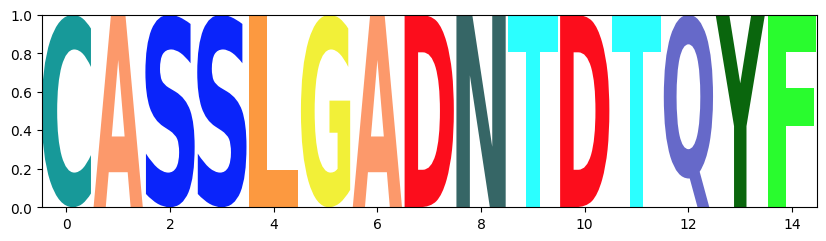

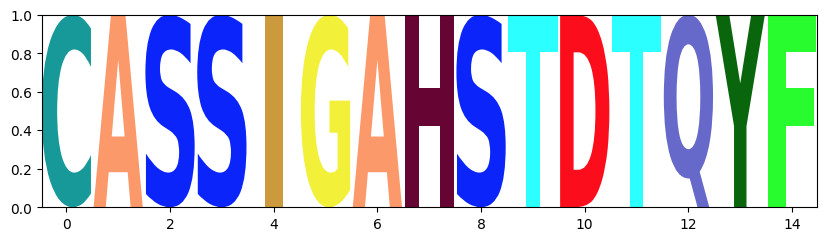

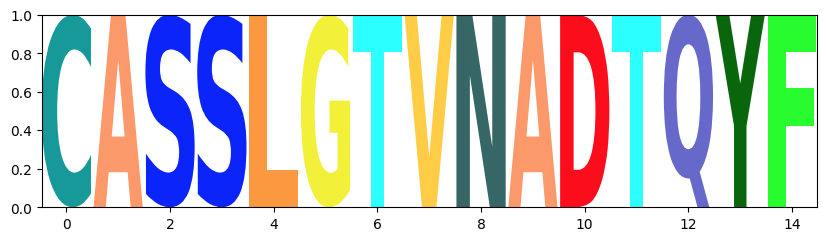

In [53]:
for i in range(8):
    seqs = dataset.clonotype_clustering[dataset.clonotype_clustering.cluster == i].cdr3aa
    mat_df = logomaker.alignment_to_matrix(seqs)
    logomaker.Logo(mat_df, color_scheme='skylign_protein', ax=None)

In [54]:
samples

26           as_Abd_PB_F
27           as_Abr_PB_F
28    as_Ash-110_PB_F_p0
29    as_Ash-111_PB_F_p0
30           as_Bal_PB_F
31           as_Bel_PB_F
32          as_Bost_PB_F
33         as_Chaad_PB_F
36            as_Dv_PB_F
37          as_Evst_PB_F
38            as_GE_PB_F
39           as_Gar_PB_F
40         as_Gonch_PB_F
43           as_Kal_PB_F
44           as_Kud_PB_F
47           as_Luk_PB_F
48          as_Mart_PB_F
51          as_Mikh_PB_F
56          as_Shep_PB_F
57          as_Tsib_PB_F
58         as_TwHM1_PB_F
60            as_Uv_PB_F
61           as_Vas_PB_F
62          as_Vats_PB_F
63           as_Vol_PB_F
65          as_Zakh_PB_F
67           as_i70_PB_F
Name: sample_name, dtype: object

In [55]:
from mir.common.parser import *
from mir.common.repertoire import Repertoire
from mir.common.repertoire_dataset import RepertoireDataset
from mir.common.clonotype_dataset import ClonotypeDataset
from mir.basic.segment_usage import *
from mir.basic.sampling import RepertoireSampling
from mir.biomarkers.fisher_biomarkers_detector import FisherBiomarkersDetector
from mir.comparative.pair_matcher import PairMatcher
import time
from pympler.asizeof import asizeof

/home/evlasova/.conda/envs/bio2025/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [56]:
metadata = metadata.reset_index(drop=True)

In [57]:
found_clonotypes

[κ-1 CASSLGLLSTDTQYF,
 κ-1 CASSLGLPSTDTQYF,
 κ-1 CASSLGLVSTDTQYF,
 κ-1 CASSLGAVETDTQYF,
 κ-1 CASSLGSIRTDTQYF,
 κ-1 CASSLGAYSTDTQYF,
 κ-1 CASSLGTVDTDTQYF,
 κ-1 CASSVGLYSTDTQYF,
 κ-1 CASSLGPTSTDTQYF,
 κ-1 CASSVGVFSTDTQYF,
 κ-1 CASSVGLYSTDTQYF,
 κ-1 CASSLGIYSTDTQYF,
 κ-1 CASSLGVPSTDTQYF,
 κ-1 CASSLGTPSTDTQYF,
 κ-1 CASSLGPTSTDTQYF,
 κ-1 CASSLGVPSTDTQYF,
 κ-1 CASSLGTPATDTQYF,
 κ-1 CASSLGLPSTDTQYF,
 κ-1 CASSVGLFSTDTQYF,
 κ-1 CASSLGLFSTDTQYF,
 κ-1 CASSLGLYSTDTQYF,
 κ-1 CASSVGVYSTDTQYF,
 κ-1 CASSLGLYSTDTQYF,
 κ-1 CASSVGLYSTDTQYF,
 κ-1 CASSVGLYSTDTQYF,
 κ-1 CASSVGVYSTDTQYF,
 κ-1 CASSLGLFSTDTQYF,
 κ-1 CASSVGLFSTDTQYF,
 κ-1 CASSVGLYSTDTQYF,
 κ-1 CASSLGADNTDTQYF,
 κ-1 CASSLGAPSTDTQYF,
 κ-1 CASSLGPTSTDTQYF,
 κ-1 CASSIGAHSTDTQYF,
 κ-1 CASSVGLYSTDTQYF,
 κ-1 CASSVGLFSTDTQYF,
 κ-1 CASSLGLYSTDTQYF,
 κ-1 CASSVGLFSTDTQYF,
 κ-1 CASSVGLFSTDTQYF,
 κ-1 CASSVGLYSTDTQYF,
 κ-1 CASSLGLFSTDTQYF,
 κ-1 CASSLGLYSTDTQYF,
 κ-1 CASSVGLFSTDTQYF,
 κ-1 CASSLGLPSTDTQYF,
 κ-1 CASSLGVPSTDTQYF,
 κ-1 CASSLGYVSTDTQYF,
 κ-1 CASSL

In [58]:
t0 = time.time()
dataset = RepertoireDataset.load(parser=AIRRParser(), 
                                 metadata=metadata,
                                 threads=16,
                                 paths=[f'/projects/immunestatus/rheum/airr_format/{r}.tsv' for r in samples], 
                                 gene='TRB')
print(time.time() - t0)

loading Repertoire objects: 100%|██████████| 27/27 [01:03<00:00,  2.33s/it]

63.57565665245056


In [59]:
dataset_found = dataset.subsample_by_lambda(lambda x: x.cdr3aa in set([x.cdr3aa for x in found_clonotypes]))

In [60]:
dataset_found.repertoire_matrix_public_clonotypes = public_clonotypes

NameError: name 'public_clonotypes' is not defined

In [ ]:
dataset_found[20]

In [ ]:
metadata_h =metadata_h.reset_index(drop=True)

In [ ]:
metadata_h

In [ ]:
from mir.comparative.pair_matcher import ClonotypeRepresentation

In [ ]:
public_clonotypes = [ClonotypeRepresentation(cdr3aa=x) for x in set(y.cdr3aa for y in found_clonotypes)]

In [ ]:
t0 = time.time()
dataset_h = RepertoireDataset.load(parser=AIRRParser(), 
                                 metadata=metadata_h,
                                 threads=16,
                                 paths=[f'/projects/immunestatus/rheum/airr_format/{r}.tsv' for r in metadata_h.sample_name], 
                                 gene='TRB')
print(time.time() - t0)

In [ ]:
dataset_h.repertoire_matrix_public_clonotypes = public_clonotypes


In [ ]:
dataset_h_found = dataset_h.subsample_by_lambda(lambda x: x.cdr3aa in set([x.cdr3aa for x in found_clonotypes]))

In [ ]:
dataset_h_found.repertoire_matrix_public_clonotypes = public_clonotypes

In [ ]:
dataset_h_found.clonotype_usage_matrix.public_clonotypes

In [ ]:
dataset_h_found[0]

In [ ]:
healthy_usage = pd.DataFrame.sparse.from_spmatrix(dataset_h_found.clonotype_usage_matrix.clonotype_database_usage,
                                 columns=[x.cdr3aa for x in dataset_h_found.clonotype_usage_matrix.public_clonotypes])

In [ ]:
as_usage = pd.DataFrame.sparse.from_spmatrix(dataset_found.clonotype_usage_matrix.clonotype_database_usage,
                                 columns=[x.cdr3aa for x in dataset_found.clonotype_usage_matrix.public_clonotypes])

In [ ]:
healthy_usage.columns

In [ ]:
as_usage.columns

In [ ]:
(healthy_usage['CASSLGAPSTDTQYF'] != 0).sum()

In [ ]:
as_usage['CASSLGLPSTDTQYF']

In [ ]:
def found_in_x_patients(usage_df, clonotype):
    # if clonotype in usage_df.columns:
    return (usage_df[clonotype] != 0).sum() 
    # return 0

In [ ]:
cluster573 = df[df.merged_cluster_id == 573]
cluster573.head()

In [ ]:
df[df.merged_cluster_id == 573]

In [ ]:
cluster573['hd_usage'] = cluster573.cdr3aa_beta.apply(lambda x: found_in_x_patients(healthy_usage, x))

In [ ]:
cluster573['as_usage'] = cluster573.cdr3aa_beta.apply(lambda x: found_in_x_patients(as_usage, x))

In [ ]:
as_usage

In [ ]:
metadata

In [ ]:
cluster573